# Environment Config

In [2]:
import gymnasium as gym
import numpy as np
import torch
!pip install stable-baselines3
from stable_baselines3 import DQN
from stable_baselines3.common.callbacks import EvalCallback, CheckpointCallback
from gym_env import SalesNegotiationEnv

import matplotlib.pyplot as plt
from utils import evaluate_strategy_dqn, evaluate_strategy_a2c
from datetime import datetime
import os
from stable_baselines3 import A2C, PPO


# DQN
Mirrors the d3rlpy DQN configuration for comparison.

## Model Config

In [3]:
class MinMaxRewardWrapper(gym.RewardWrapper):
    def __init__(self, env, r_min=-10.0, r_max=10.0):
        super().__init__(env)
        self.r_min = r_min
        self.r_max = r_max

    def reward(self, reward):
        return (reward - self.r_min) / (self.r_max - self.r_min) * 2 - 1

train_env = MinMaxRewardWrapper(SalesNegotiationEnv(exit_start_round=7))
eval_env = SalesNegotiationEnv(exit_start_round=7)

model = DQN(
    "MlpPolicy",
    train_env,
    # network architecture
    policy_kwargs={"net_arch": [128, 64]},
    # RL hyperparameters
    gamma=0.99,
    target_update_interval=20_000,
    learning_starts=40_000,
    train_freq=4,
    # epsilon greedy
    exploration_initial_eps=1.0,
    exploration_final_eps=0.05,
    exploration_fraction=0.25,  # 100000 / 400000
    # training hyperparameters
    learning_rate=3e-5,
    #max_grad_norm=1, # gradient clipping
    batch_size=256,
    # Buffer, prioritized replay buffer prioritizes replay that has higher TD error
    buffer_size=50_000,
    #replay_buffer_class=PrioritizedReplayBuffer,
    #replay_buffer_kwargs={"alpha": 0.6},
    # logging
    tensorboard_log="./sb3_logs/",
    verbose=1,
)

Using cuda device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## 2. Training

In [4]:
from stable_baselines3.common.callbacks import CheckpointCallback

timestamp = datetime.now().strftime("%Y%m%d_%H%M")

eval_callback = EvalCallback(
    eval_env,
    best_model_save_path="./models/best/",
    log_path=f"./sb3_logs/DQN_{timestamp}/",
    eval_freq=5_000,
    n_eval_episodes=1000,
    deterministic=True, #deterministic action for evaluation
)

checkpoint_callback = CheckpointCallback(
    save_freq=5_000,
    save_path=f"./models/DQN_{timestamp}/checkpoints/",
    name_prefix="dqn",
)

model.learn(total_timesteps=400_000, callback=[eval_callback, checkpoint_callback])

# save best model
os.makedirs("./models", exist_ok=True)
model.save(f"./models/dqn_{timestamp}")
print(f"Model saved to ./models/dqn_{timestamp}.zip")

流式输出内容被截断，只能显示最后 5000 行内容。
| time/               |          |
|    episodes         | 672      |
|    fps              | 2325     |
|    time_elapsed     | 0        |
|    total_timesteps  | 1402     |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 2.04     |
|    ep_rew_mean      | -0.0174  |
|    exploration_rate | 0.987    |
| time/               |          |
|    episodes         | 676      |
|    fps              | 2323     |
|    time_elapsed     | 0        |
|    total_timesteps  | 1410     |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 2.01     |
|    ep_rew_mean      | -0.0278  |
|    exploration_rate | 0.987    |
| time/               |          |
|    episodes         | 680      |
|    fps              | 2320     |
|    time_elapsed     | 0        |
|    total_timesteps  | 1414     |
----------------------------

/usr/local/lib/python3.12/dist-packages/stable_baselines3/common/evaluation.py:70: UserWarning: Evaluation environment is not wrapped with a ``Monitor`` wrapper. This may result in reporting modified episode lengths and rewards, if other wrappers happen to modify these. Consider wrapping environment first with ``Monitor`` wrapper.
  warnings.warn(


流式输出内容被截断，只能显示最后 5000 行内容。
|    learning_rate    | 3e-05    |
|    loss             | 0.0178   |
|    n_updates        | 88534    |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 4.72     |
|    ep_rew_mean      | 0.0792   |
|    exploration_rate | 0.05     |
| time/               |          |
|    episodes         | 101244   |
|    fps              | 127      |
|    time_elapsed     | 3093     |
|    total_timesteps  | 394161   |
| train/              |          |
|    learning_rate    | 3e-05    |
|    loss             | 0.014    |
|    n_updates        | 88540    |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 4.86     |
|    ep_rew_mean      | 0.0654   |
|    exploration_rate | 0.05     |
| time/               |          |
|    episodes         | 101248   |
|    fps              | 127      |
|    time_elapsed     | 3093

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 3. Evaluation

### 3.1 Best Model Evaluation

#### Helper Function: Plot Reward Distribution and Episode Length Distribution

In [11]:
def plot_reward_and_round_distributions(rewards, round_counts, output_file_name):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].hist(rewards, bins=30, edgecolor="black", alpha=0.7)
    axes[0].set_yscale('log')
    axes[0].set_xlabel("Reward Distribution")
    axes[0].set_ylabel("Count")
    axes[0].set_title(f"Reward Distribution (n={len(rewards)})")
    axes[0].axvline(np.mean(rewards), color="red", linestyle="--", label=f"Mean: {np.mean(rewards):.2f}")
    axes[0].legend()

    # Use integer bins from 1 up to the max episode length (inclusive)
    bins = np.arange(1, max(round_counts) + 2) - 0.5
    axes[1].hist(round_counts, bins=bins, edgecolor="black", alpha=0.7)
    axes[1].set_xticks(np.arange(1, max(round_counts) + 1))
    axes[1].set_ylabel("Count")
    axes[1].set_title(f"Round Count Distribution (n={len(round_counts)})")
    axes[1].axvline(np.mean(round_counts), color="red", linestyle="--", label=f"Mean: {np.mean(round_counts):.1f}")
    axes[1].legend()

    plt.tight_layout()
    plt.savefig(output_file_name, dpi=300, bbox_inches='tight')
    plt.show()

import matplotlib.pyplot as plt
import numpy as np
from collections import defaultdict

def plot_action_distribution(action_history_record, round_count_record, output_path="action_distribution.png"):
    """
    Plot a stacked area chart of action distribution at each round.

    Args:
        action_history_record: list of lists, each inner list is the action sequence for one episode
        round_count_record: list of ints, number of rounds per episode
        output_path: file path to save the figure
    """
    max_rounds = max(round_count_record)

    # Count actions at each round
    action_counts = defaultdict(lambda: {0: 0, 1: 0, 2: 0})
    episodes_at_round = defaultdict(int)

    for actions in action_history_record:
        for r, a in enumerate(actions):
            action_counts[r + 1][a] += 1
            episodes_at_round[r + 1] += 1

    # Convert to percentages
    rounds = list(range(1, max_rounds + 1))
    pct = {a: [] for a in [0, 1, 2]}

    for r in rounds:
        total = episodes_at_round[r]
        for a in [0, 1, 2]:
            pct[a].append(action_counts[r][a] / total * 100 if total > 0 else 0)

    # Plot
    fig, ax = plt.subplots(figsize=(10, 6))

    colors = ['#4C72B0', '#DD8452', '#55A868']
    labels = ['Persuade (0)', 'Incentive (1)', 'Closing (2)']

    ax.stackplot(rounds, pct[0], pct[1], pct[2],
                 labels=labels, colors=colors, alpha=0.85)

    ax.set_xlabel('Round', fontsize=12)
    ax.set_ylabel('Action Distribution (%)', fontsize=12)
    ax.set_title('DQN Agent Action Distribution by Round', fontsize=14)
    ax.set_xlim(1, max_rounds)
    ax.set_ylim(0, 100)
    ax.legend(loc='upper right', fontsize=10)
    ax.grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.savefig(output_path, dpi=150, bbox_inches='tight')
    plt.show()

#### Reward Distribution and Episode Length

We evaluate 1000 episodes using the best model selected by SB3.

In [20]:
rewards, round_counts, last_action_record, topic_history_record, action_history_record  = evaluate_strategy_dqn(model, eval_env, n_episodes=1000, verbose=True)
print(f"Conversion Rate: {(np.array(rewards) > 0).sum() / len(rewards): .2%}\n\n Average Reward: {np.mean(rewards)}.")


Evaluating DQN: 100%|██████████| 1000/1000 [00:14<00:00, 70.65it/s]

Conversion Rate:  46.00%

 Average Reward: 1.6614000000000007.


In [21]:
import pandas as pd

df = pd.DataFrame({
    "reward": rewards,
    "rounds": round_counts,
    "last_action": last_action_record,
    "topic_history": topic_history_record,
    "action_history": action_history_record
})

# Save the DataFrame to a CSV file
timestamp = datetime.now().strftime("%Y%m%d_%H%M")
csv_path = f'experiment/DQN_results_{timestamp}.csv'
df.to_csv(csv_path, index=False)
print(f"Saved evaluation results to {csv_path}")

Saved evaluation results to experiment/DQN_results_20260312_0414.csv


/usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:2170: PyparsingDeprecationWarning: 'parseString' deprecated - use 'parse_string'
  result = self._expression.parseString(s)
/usr/local/lib/python3.12/dist-packages/pyparsing/util.py:466: PyparsingDeprecationWarning: 'parseAll' argument is deprecated, use 'parse_all'
  return fn(self, *args, **kwargs)
/usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:2178: PyparsingDeprecationWarning: 'resetCache' deprecated - use 'reset_cache'
  ParserElement.resetCache()


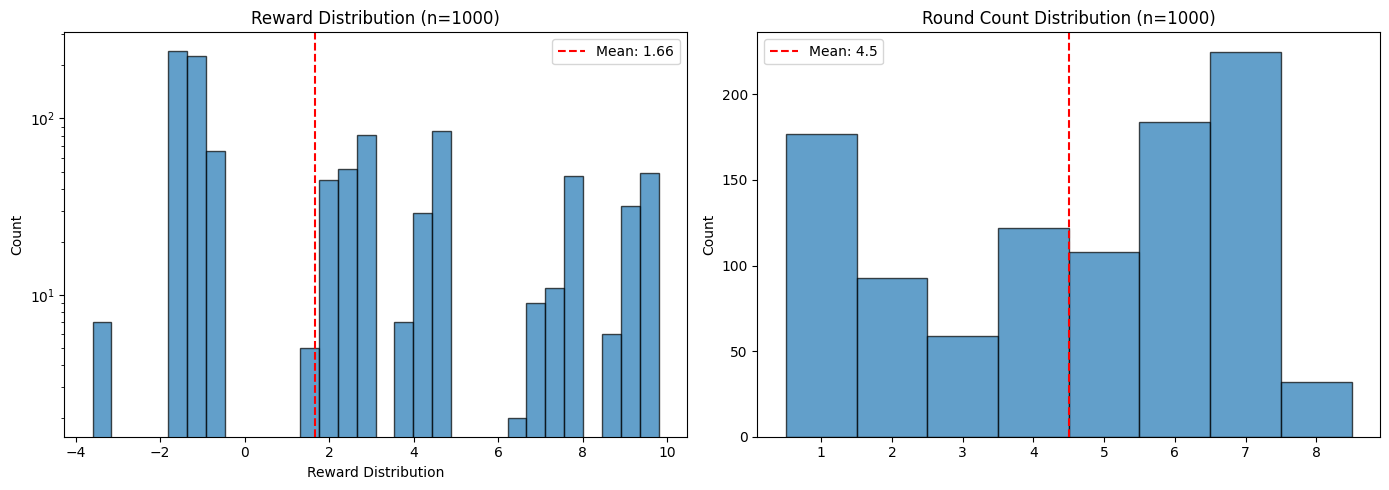

In [22]:
timestamp = datetime.now().strftime("%Y%m%d_%H%M")
plot_reward_and_round_distributions(rewards, round_counts, output_file_name=f'plot/ep_reward_len/DQN_results_{timestamp}.png')


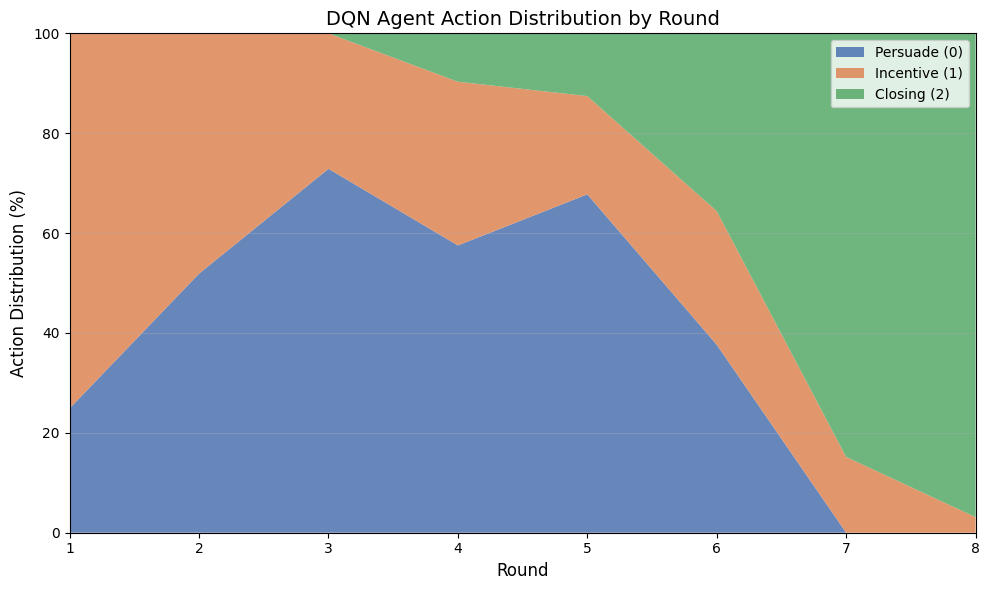

In [24]:
plot_action_distribution(action_history_record, round_counts, output_path=f'plot/action_distribution/DQN_{timestamp}.png')

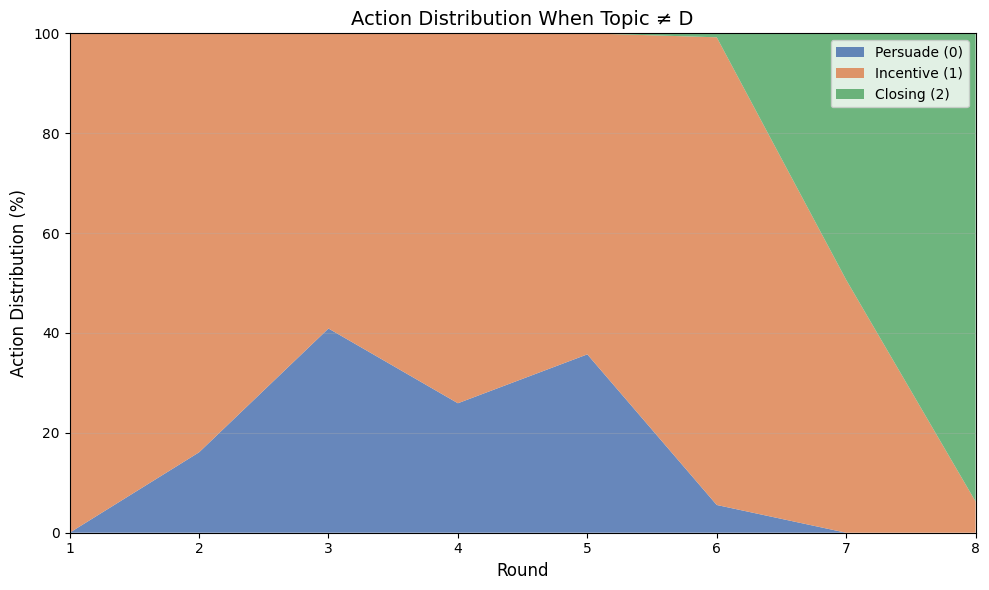

In [25]:
def plot_action_distribution_non4(action_history_record, topic_history_record, output_path="action_distribution.png"):
    """
    Plot stacked area chart of action distribution at each round,
    only counting steps where the topic is not 4.

    Args:
        action_history_record: list of lists, action sequence per episode
        topic_history_record: list of lists, topic sequence per episode
        output_path: file path to save the figure
    """
    action_counts = defaultdict(lambda: {0: 0, 1: 0, 2: 0})
    step_counts = defaultdict(int)

    for actions, topics in zip(action_history_record, topic_history_record):
        for r, (a, t) in enumerate(zip(actions, topics)):
            if t != 4:
                action_counts[r + 1][a] += 1
                step_counts[r + 1] += 1

    max_round = max(step_counts.keys())
    rounds = list(range(1, max_round + 1))
    pct = {a: [] for a in [0, 1, 2]}

    for r in rounds:
        total = step_counts[r]
        for a in [0, 1, 2]:
            pct[a].append(action_counts[r][a] / total * 100 if total > 0 else 0)

    fig, ax = plt.subplots(figsize=(10, 6))

    colors = ['#4C72B0', '#DD8452', '#55A868']
    labels = ['Persuade (0)', 'Incentive (1)', 'Closing (2)']

    ax.stackplot(rounds, pct[0], pct[1], pct[2],
                 labels=labels, colors=colors, alpha=0.85)

    ax.set_xlabel('Round', fontsize=12)
    ax.set_ylabel('Action Distribution (%)', fontsize=12)
    ax.set_title('Action Distribution When Topic ≠ D', fontsize=14)
    ax.set_xlim(1, max_round)
    ax.set_ylim(0, 100)
    ax.legend(loc='upper right', fontsize=10)
    ax.grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.savefig(output_path, dpi=150, bbox_inches='tight')
    plt.show()

plot_action_distribution_non4(
    action_history_record, topic_history_record,
    output_path=f"plot/action_distribution/DQN_{timestamp}_excl_D.png"
)

In [27]:
!zip -r DQN_exit7_20260312_0017.zip . -x "drive/*" "sample_data/*"

  adding: .config/ (stored 0%)
  adding: .config/gce (stored 0%)
  adding: .config/hidden_gcloud_config_universe_descriptor_data_cache_configs.db (deflated 97%)
  adding: .config/active_config (stored 0%)
  adding: .config/configurations/ (stored 0%)
  adding: .config/configurations/config_default (deflated 15%)
  adding: .config/logs/ (stored 0%)
  adding: .config/logs/2026.02.06/ (stored 0%)
  adding: .config/logs/2026.02.06/14.30.32.592228.log (deflated 92%)
  adding: .config/logs/2026.02.06/14.31.28.771044.log (deflated 86%)
  adding: .config/logs/2026.02.06/14.31.44.938153.log (deflated 57%)
  adding: .config/logs/2026.02.06/14.31.35.535753.log (deflated 58%)
  adding: .config/logs/2026.02.06/14.31.19.332851.log (deflated 58%)
  adding: .config/logs/2026.02.06/14.31.45.734270.log (deflated 56%)
  adding: .config/default_configs.db (deflated 98%)
  adding: .config/.last_survey_prompt.yaml (stored 0%)
  adding: .config/.last_opt_in_prompt.yaml (stored 0%)
  adding: .config/config_se